# Random variables

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---

We will cover how to generate random variables according to a variety of distributions.

We will use a scientific library called Numpy, which provides high-performance libraries to deal with multi-dimensional arrays (which are like Python lists).

We will use Numpy to generate random variables according to some distribution.  See the docs at:  https://het.as.utexas.edu/HET/Software/Numpy/reference/routines.random.html


In [1]:
import numpy as np

In [2]:
# A python list
lst = [1,2,4,5,5]
print(f"A python list: {lst}")


A python list: [1, 2, 4, 5, 5]


In [3]:
# create a numpy array from a python list
arr = np.array(lst)
print(f"A numpy array: {arr}")

A numpy array: [1 2 4 5 5]


In [4]:
back_to_list = arr.tolist()
print(f"Back to a python list: {back_to_list}")


Back to a python list: [1, 2, 4, 5, 5]


In [5]:
lst = [1, 2, 3, 4, 5.88]
print(f"A python list: {lst}")
arr = np.array(lst)
print(f"A numpy array: {arr}")
print(f"The first element {arr[0]} is of type {type(arr[0])}")

A python list: [1, 2, 3, 4, 5.88]
A numpy array: [1.   2.   3.   4.   5.88]
The first element 1.0 is of type <class 'numpy.float64'>


### Uniform floating point random variables  

In [6]:
# Generate a random float between 0 and 1
x = np.random.rand()
print(x)

0.12686253689409122


In [7]:
# Generate a random float between 4 and 10
x = np.random.uniform(4,10)
print(x)

4.389555958364559


In [8]:
# Generate 3 random float between 4 and 10
x = np.random.uniform(4,10,size=3)
print(x)

[6.35657799 8.48333836 4.7845703 ]


In [9]:
# Generate a random integer between 4 and 10 (does not include 10)
x = np.random.randint(4,10, size=100)
print(x)

[8 7 9 4 9 4 6 4 6 4 7 9 6 7 5 4 4 9 9 7 7 5 8 6 5 4 5 9 4 4 4 4 7 7 4 9 7
 7 4 5 5 7 6 8 6 9 7 7 4 7 9 5 8 7 5 5 9 9 9 9 5 8 9 8 7 9 9 4 9 8 7 4 9 5
 6 9 4 9 5 8 9 4 4 4 4 5 4 9 7 9 8 8 7 9 4 6 5 7 5 5]


In [10]:
np.random.seed(431)
x = np.random.uniform(4,10)
print(x)
x = np.random.uniform(4,10)
print(x)

9.5474179805637
6.878131125086931


### Uniform integer random variables

### The useful `unique` method

In [11]:
arr = np.array([1,2,3,3,3,1,1,4,5,5,2])
np.unique(arr)

array([1, 2, 3, 4, 5])

## A Challenge
Your intro probability class might have attempted to convince you that it only takes about 23 random birthdays to have a 50% chance of two being the same.

1) First generate 23 random birthdays ... and determine if any of them are the same?
2) Now, run the 23 random birthday experiment 1000 times, what proportion of the experiments resulted in at least one duplicated birthday?  


In [12]:
birth_day = np.random.randint(1,31,size=23)
birth_month = np.random.randint(1,13, size = 23)
#create the month-day pairings
birth_dates = [(m,d) for m, d in zip(birth_month, birth_day)]

#check to see if there are duplicates a.k.a. if the set has less entries than the original length of the array 
if len(set(birth_dates)) != len(birth_dates):
    diff = len(birth_dates) - len(set(birth_dates))
    print(f"There are {diff} duplicate birthdays")
else:
    print("There are no duplicate birthdays")

In [15]:
#1000 run set up:
def birthday_experiment():
    # Generate the data
    birth_day = np.random.randint(1, 32, size=23)
    birth_month = np.random.randint(1, 13, size=23)
    
    # Pair them
    birth_dates = [(m,d) for m, d in zip(birth_month, birth_day)]
    
    # Check for duplicates (Returns True if there is a duplicate)
    return len(set(birth_dates)) != len(birth_dates)

num_simulations = 1000
duplicate_count = 0

for i in range(num_simulations):
    if birthday_experiment():
        duplicate_count += 1

# Calculate the proportion
proportion = duplicate_count / num_simulations

print(f"Out of {num_simulations} experiments, {duplicate_count} had at least one shared birthday.")
print(f"Proportion: {proportion * 100}%")

Out of 1000 experiments, 478 had at least one shared birthday.
Proportion: 47.8%


### Choose and Shuffle

In [21]:
# Select a random item from a list (array)
lst = [1,2,3,4,5]
x = np.random.choice(lst)
print(x)

5


In [29]:
lst = [1,2,3,4,5]
x = np.random.shuffle(lst)
print(lst)

[5, 3, 1, 4, 2]


### Normal Random Variables

In [39]:
# Generate a normal rv with mean 10 and std dev of 8
x = np.random.normal(10,8)
print(x)

8.316138710555993


In [43]:
x = np.random.normal(10,8, size=50)
print(x)

[ 6.80160378 12.8510987  -0.39245868  4.13468209  9.2926875  -0.8055773
  9.38836375  5.31972524  6.7010552  20.26289871 30.00810624  7.17001159
  8.66473636  9.10982959 -1.63134133 -3.50645641 14.36912045 11.22512214
 23.0594466  21.21996286 10.0884134  16.92270536  1.68775987 17.83674146
  9.18676394 13.97561986 18.70248338 20.81134752 -0.20203191 13.79133199
  2.90042056  6.84683923  9.93468767  3.7129745   9.11284823 15.84436129
  8.52696442 -4.05669988 24.11948161  7.28687097  6.74783177 12.41890463
  5.02277621  1.20622581  6.17626075 13.01923682 24.47364259 21.90396642
 21.62167973 17.14086655]


### Compute mean and standard dev from a list, and convert to integers, and truncate at 0

In [44]:
np.mean(x)
np.std(x)

np.float64(7.963609273291307)

### Truncate and Lower bounds 

In [45]:
#truncate all elements to integers
x_int = x.astype(int)
print(x_int)


[ 6 12  0  4  9  0  9  5  6 20 30  7  8  9 -1 -3 14 11 23 21 10 16  1 17
  9 13 18 20  0 13  2  6  9  3  9 15  8 -4 24  7  6 12  5  1  6 13 24 21
 21 17]


In [46]:
# Enforce a lowerbound of zero
x_clipped = x.clip(0)
print(x_clipped)

[ 6.80160378 12.8510987   0.          4.13468209  9.2926875   0.
  9.38836375  5.31972524  6.7010552  20.26289871 30.00810624  7.17001159
  8.66473636  9.10982959  0.          0.         14.36912045 11.22512214
 23.0594466  21.21996286 10.0884134  16.92270536  1.68775987 17.83674146
  9.18676394 13.97561986 18.70248338 20.81134752  0.         13.79133199
  2.90042056  6.84683923  9.93468767  3.7129745   9.11284823 15.84436129
  8.52696442  0.         24.11948161  7.28687097  6.74783177 12.41890463
  5.02277621  1.20622581  6.17626075 13.01923682 24.47364259 21.90396642
 21.62167973 17.14086655]


### The exponential distribution is commonly used to simulate the time between random arrivals to a system

In [49]:
# generate exponential rv with a mean of 10
x= np.random.exponential(10, size = 15000)


Text(0.5, 0, 'Data')

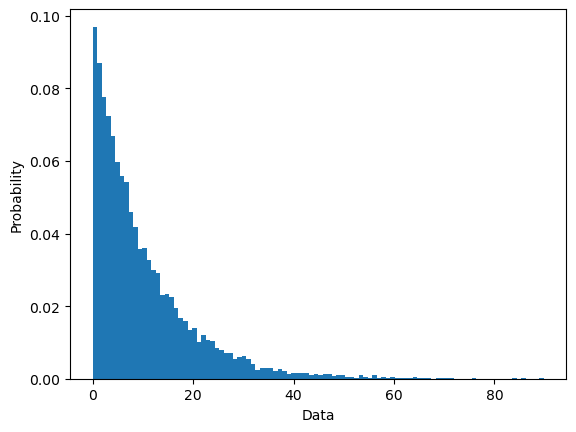

In [50]:
import matplotlib.pyplot as plt
plt.hist(x, density = True, bins = 100)
plt.ylabel('Probability')
plt.xlabel('Data')